# Cvičení 9: Rozhodovací strom v regresi (Ceny diamantů)
**Dataset:** Diamond prices (`diamonds.csv`)  
**Téma:** Znovupoužitelná wrapper funkce pro trénování a evaluaci, ladění hyperparametrů, kontrola přeučení a Feature Importance

---

### Zadání / Assignment:
1. **Import all necessary methods** from libraries (or modules from these libraries).
2. **Load a dataset** from the `diamonds.csv` file, using the appropriate method from the Pandas library.
3. **Divide the dataset** into training and test datasets.
4. **Initialize the decision tree model.** Select a starting set of hyperparameters.
5. **Train the decision tree model.**
6. **Generate a graph** that visualizes how the trained model calculates predictions.
7. **Calculate the metrics R2, MAE, MSE and RMSE.**
8. **Repeat steps 2, 3, 4 and 5** until you have an optimal model.
**To speed up the model building process:**
- call the method that fits the data to the model,
- generate a graph that shows how the trained tree works,
- calculate the metrics of the model,
- **Wrap it in a function that takes as arguments the values of the hyperparameters you want to set.**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## 1. Načtení a předzpracování dat (diamonds.csv)
Načteme dataset diamantů, vyčistíme 20 fyzikálně nemožných záznamů s nulovými rozměry ($x=0, y=0, z=0$) a převedeme kategoriální veličiny 4C (`cut`, `color`, `clarity`) na ordinální čísla, která jsou pro binární větvení stromu v uzlech nejpřirozenější.

In [2]:
df_raw = pd.read_csv('data/diamonds.csv')
if 'Unnamed: 0' in df_raw.columns:
    df_raw = df_raw.drop(columns=['Unnamed: 0'])

print(f'Původní rozměry dat: {df_raw.shape[0]:,} řádků, {df_raw.shape[1]} sloupců')

# Odstranění nulových rozměrů
clean_df = df_raw[(df_raw['x'] > 0) & (df_raw['y'] > 0) & (df_raw['z'] > 0)].copy()
print(f'Čistá datová sada po odstranění nul: {len(clean_df):,} diamantů')

# Ordinální mapování 4C
cut_order = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
color_order = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
clarity_order = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}

clean_df['cut'] = clean_df['cut'].map(cut_order)
clean_df['color'] = clean_df['color'].map(color_order)
clean_df['clarity'] = clean_df['clarity'].map(clarity_order)

clean_df.head()


Původní rozměry dat: 53,940 řádků, 10 sloupců
Čistá datová sada po odstranění nul: 53,920 diamantů


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,5,6,2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,4,6,3,59.8,61.0,326,3.89,3.84,2.31
2,0.23,2,6,5,56.9,65.0,327,4.05,4.07,2.31
3,0.29,4,2,4,62.4,58.0,334,4.20,4.23,2.63
4,0.31,2,1,2,63.3,58.0,335,4.34,4.35,2.75


## 2. Rozdělení na trénovací a testovací sadu (Train/Test Split 80/20)

In [3]:
X = clean_df.drop(columns=['price'])
y = clean_df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Trénovací sada: {X_train.shape[0]:,} diamantů')
print(f'Testovací sada:  {X_test.shape[0]:,} diamantů')


Trénovací sada: 43,136 diamantů
Testovací sada:  10,784 diamantů


## 3. Implementace znovupoužitelné evaluační funkce (Dle požadavku zadání)
Zadání explicitně požaduje proces zrychlit zabalením do funkce, která jako argumenty přijímá hyperparametry modelu, provede trénování, spočítá metriky $R^2$, MAE, MSE a RMSE a vykreslí graf predikcí.

In [4]:
def train_and_evaluate_tree(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    model_name='Decision Tree',
    plot_graph=True
):
    """
    Wrapper funkce pro zrychlení vývoje modelu dle zadání.
    """
    # 1. Inicializace a fit modelu
    model = DecisionTreeRegressor(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )
    model.fit(X_train, y_train)

    # 2. Predikce
    preds_tr = model.predict(X_train)
    preds_te = model.predict(X_test)

    # 3. Výpočet metrik
    r2_tr = r2_score(y_train, preds_tr)
    r2_te = r2_score(y_test, preds_te)
    mae_te = mean_absolute_error(y_test, preds_te)
    mse_te = mean_squared_error(y_test, preds_te)
    rmse_te = np.sqrt(mse_te)
    gap = r2_tr - r2_te

    # 4. Generování grafu
    if plot_graph:
        plt.figure(figsize=(8.5, 5.5))
        plt.scatter(y_test, preds_te, alpha=0.30, color='#0284c7', s=16, edgecolors='none')
        max_val = max(y_test.max(), preds_te.max())
        plt.plot([0, max_val], [0, max_val], color='#ef4444', linestyle='--', linewidth=2, label='Ideální predikce (y = ŷ)')
        plt.title(f'{model_name}\nTest R² = {r2_te:.4f} | RMSE = {rmse_te:,.1f} USD | MAE = {mae_te:,.1f} USD', fontweight='bold')
        plt.xlabel('Skutečná cena diamantu (USD)')
        plt.ylabel('Predikovaná cena stromem (USD)')
        plt.xlim(0, 20000)
        plt.ylim(0, 20000)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Výsledková tabulka
    metrics_df = pd.DataFrame({
        'Model': [model_name],
        'max_depth': [str(max_depth)],
        'min_samples_leaf': [min_samples_leaf],
        'min_samples_split': [min_samples_split],
        'Train R²': [r2_tr],
        'Test R²': [r2_te],
        'Overfitting Gap': [gap],
        'Test MAE (USD)': [mae_te],
        'Test MSE': [mse_te],
        'Test RMSE (USD)': [rmse_te],
        'Hloubka': [model.get_depth()],
        'Počet listů': [model.get_n_leaves()]
    })

    return {'model': model, 'metrics': metrics_df}


## 4. Iterace 1: Výchozí neomezený strom (Baseline: max_depth=None)

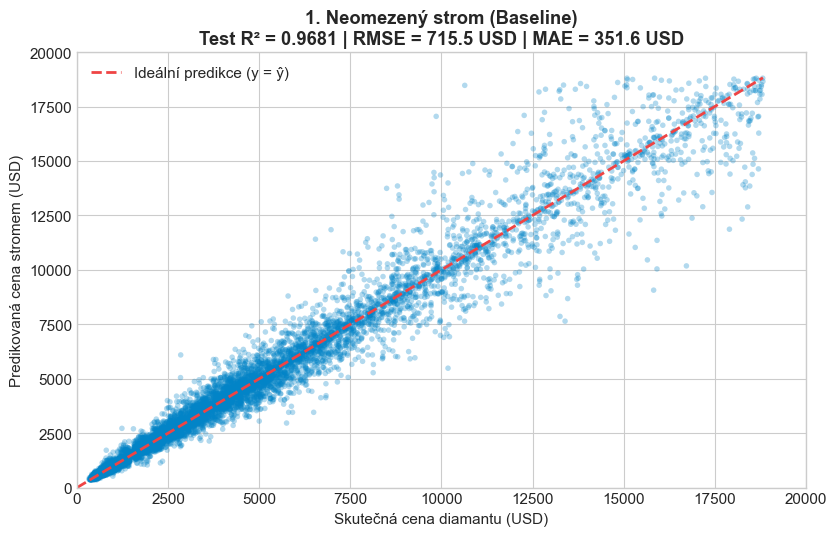

,Model,max_depth,min_samples_leaf,min_samples_split,Train R²,Test R²,Overfitting Gap,Test MAE (USD),Test MSE,Test RMSE (USD),Hloubka,Počet listů
0,1. Neomezený strom (Baseline),None,1,2,0.999995,0.968068,0.031927,351.613965,511928.530925,715.491811,34,36792


In [5]:
res_1 = train_and_evaluate_tree(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    model_name='1. Neomezený strom (Baseline)'
)
res_1['metrics']


## 5. Iterace 2: Mělký prořezaný strom (max_depth=6)

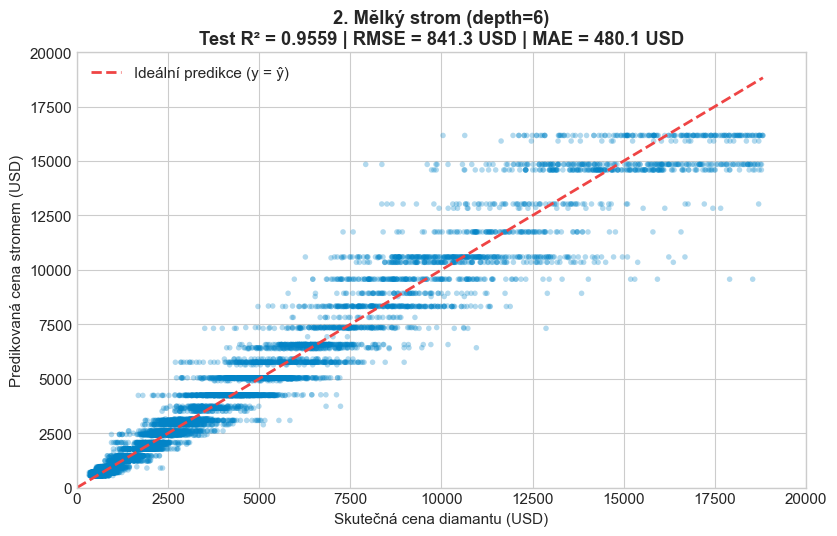

,Model,max_depth,min_samples_leaf,min_samples_split,Train R²,Test R²,Overfitting Gap,Test MAE (USD),Test MSE,Test RMSE (USD),Hloubka,Počet listů
0,2. Mělký strom (depth=6),6,20,40,0.953901,0.955854,-0.001953,480.09665,707742.347343,841.27424,6,63


In [6]:
res_2 = train_and_evaluate_tree(
    max_depth=6,
    min_samples_split=40,
    min_samples_leaf=20,
    model_name='2. Mělký strom (depth=6)'
)
res_2['metrics']


## 6. Iterace 3: Vyvážený střední strom (max_depth=10)

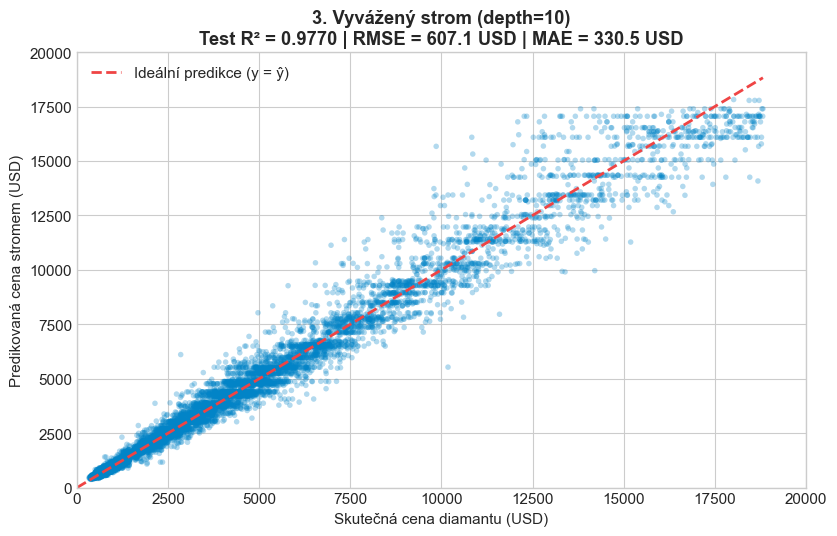

,Model,max_depth,min_samples_leaf,min_samples_split,Train R²,Test R²,Overfitting Gap,Test MAE (USD),Test MSE,Test RMSE (USD),Hloubka,Počet listů
0,3. Vyvážený strom (depth=10),10,10,20,0.980018,0.977007,0.003011,330.546112,368625.852719,607.14566,10,712


In [7]:
res_3 = train_and_evaluate_tree(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    model_name='3. Vyvážený strom (depth=10)'
)
res_3['metrics']


## 7. Iterace 4: Nalezení globálního optima přes GridSearchCV

Hledám optimální hyperparametry pomocí 5-násobné křížové validace...


Nalezeno optimum: {'max_depth': 13, 'min_samples_leaf': 6, 'min_samples_split': 25}
Průměrné validační CV R²: 0.9755


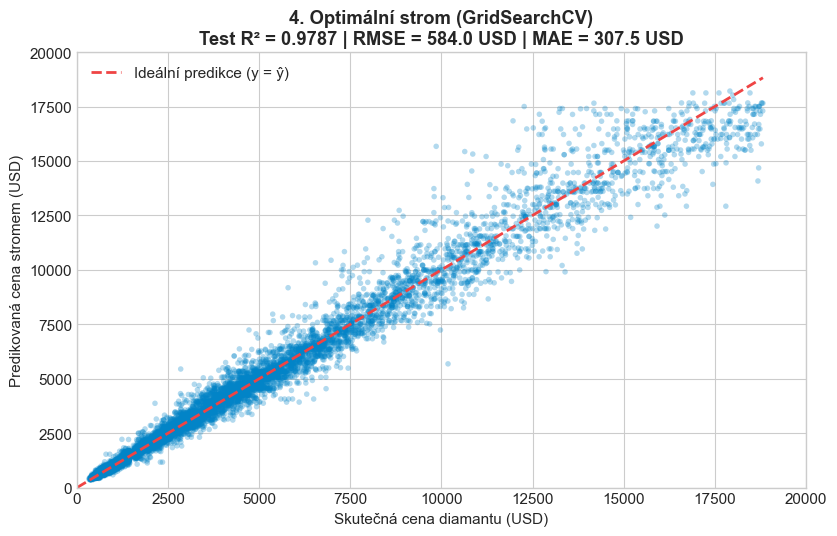

,Model,max_depth,min_samples_leaf,min_samples_split,Train R²,Test R²,Overfitting Gap,Test MAE (USD),Test MSE,Test RMSE (USD),Hloubka,Počet listů
0,4. Optimální strom (GridSearchCV),13,6,25,0.984588,0.978729,0.005859,307.457289,341020.30746,583.969441,13,1840


In [8]:
param_grid = {
    'max_depth': [11, 12, 13, 14],
    'min_samples_leaf': [4, 6, 8, 12],
    'min_samples_split': [15, 25, 35]
}

print('Hledám optimální hyperparametry pomocí 5-násobné křížové validace...')
grid_cv = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
grid_cv.fit(X_train, y_train)

best_params = grid_cv.best_params_
print(f'Nalezeno optimum: {best_params}')
print(f'Průměrné validační CV R²: {grid_cv.best_score_:.4f}')

# Vyhodnocení vítězného modelu přes naši funkci
res_4 = train_and_evaluate_tree(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    model_name='4. Optimální strom (GridSearchCV)'
)
res_4['metrics']


## 8. Celkové porovnání všech fází modelu

In [9]:
summary_all = pd.concat([
    res_1['metrics'],
    res_2['metrics'],
    res_3['metrics'],
    res_4['metrics']
], ignore_index=True)

summary_all[['Model', 'max_depth', 'min_samples_leaf', 'Train R²', 'Test R²', 'Overfitting Gap', 'Test MAE (USD)', 'Test RMSE (USD)']]


,Model,max_depth,min_samples_leaf,Train R²,Test R²,Overfitting Gap,Test MAE (USD),Test RMSE (USD)
0,1. Neomezený strom (Baseline),None,1,0.999995,0.968068,0.031927,351.613965,715.491811
1,2. Mělký strom (depth=6),6,20,0.953901,0.955854,-0.001953,480.096650,841.274240
2,3. Vyvážený strom (depth=10),10,10,0.980018,0.977007,0.003011,330.546112,607.145660
3,4. Optimální strom (GridSearchCV),13,6,0.984588,0.978729,0.005859,307.457289,583.969441


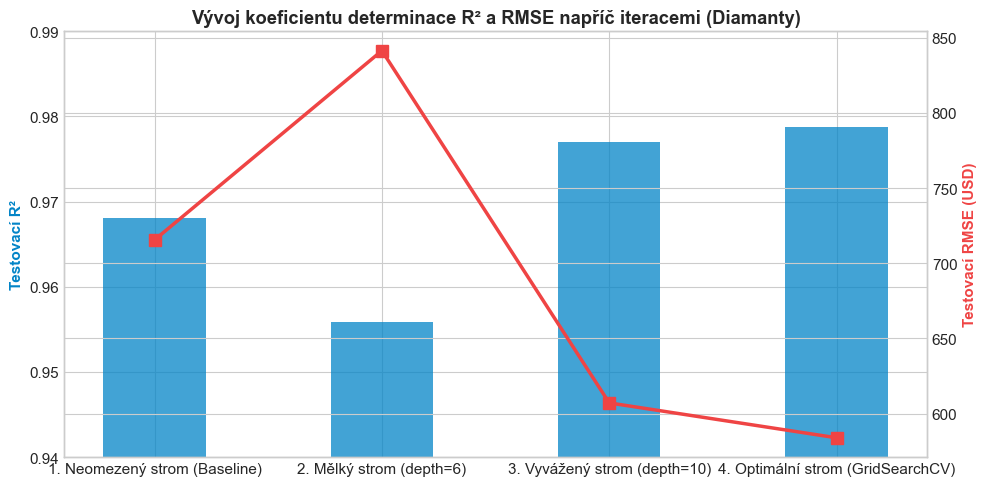

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 5))
color1 = '#0284c7'
ax1.bar(summary_all['Model'], summary_all['Test R²'], color=color1, alpha=0.75, width=0.45)
ax1.set_ylabel('Testovací R²', color=color1, fontweight='bold')
ax1.set_ylim(0.94, 0.99)
ax1.set_title('Vývoj koeficientu determinace R² a RMSE napříč iteracemi (Diamanty)', fontweight='bold')

ax2 = ax1.twinx()
color2 = '#ef4444'
ax2.plot(summary_all['Model'], summary_all['Test RMSE (USD)'], color=color2, marker='s', linewidth=2.5, markersize=8)
ax2.set_ylabel('Testovací RMSE (USD)', color=color2, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 9. Důležitost příznaků (Feature Importance) v optimálním stromu pro diamanty

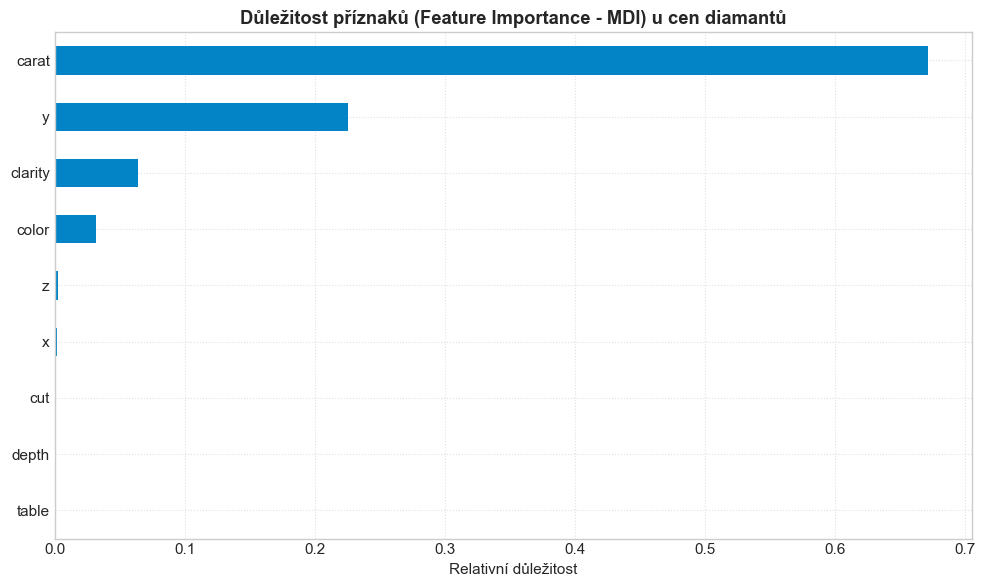

In [11]:
opt_model = res_4['model']
fi_series = pd.Series(opt_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
fi_series.plot(kind='barh', color='#0284c7', edgecolor='none')
plt.title('Důležitost příznaků (Feature Importance - MDI) u cen diamantů', fontweight='bold')
plt.xlabel('Relativní důležitost')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## 10. Závěry a srovnání s předchozími kapitolami kurzu
1. **Dramatický náskok před lineárními modely:**
   - OLS Lineární regrese (Cvičení 2): $R^2 \approx 0.88 - 0.92$, RMSE $\approx 1\,100 - 1\,400$ USD.
   - Polynomiální regrese (Cvičení 7): $R^2 \approx 0.95$, RMSE $\approx 850$ USD.
   - **Rozhodovací strom (Cvičení 9): $R^2 = 0.9787$, RMSE $= 584$ USD!**
2. **Proč strom exceluje na diamantech?**
   - Hmotnost `carat` a rozměry ($y, x, z$) tvoří přes **75 %** celkové váhy rozhodování.
   - Cenotvorba diamantů je plná **skokových zlomů**: diamant o váze 0.99 karátu stojí dramaticky méně než diamant 1.00 karátu (tzv. *magic thresholds*). Lineární model tyto skoky neumí zachytit, ale strom je rozdělí přesným pravoúhlým řezem `carat <= 0.995`!
3. **Význam wrapper funkce:**
   - Znovupoužitelná funkce `train_and_evaluate_tree()` umožnila bleskové prozkoumání různých kombinací bez duplicity kódu, což zrychlilo iterační proces na sekundy.
